<a href="https://colab.research.google.com/github/RiddhiSinha123/Customer-Churn-Prediction/blob/main/CustomerChurnPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv('telecom_customer_churn.csv')

In [ ]:
df.head(5)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [ ]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason'],
      dtype='object')

In [ ]:
df1 = df.copy()

In [ ]:
df1.head(7)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability
5,0013-MHZWF,Female,23,No,3,Midpines,95345,37.581496,-119.972762,0,...,Credit Card,69.4,571.45,0.00,0,150.93,722.38,Stayed,NaN,NaN
6,0013-SMEOE,Female,67,Yes,0,Lompoc,93437,34.757477,-120.550507,1,...,Bank Withdrawal,109.7,7904.25,0.00,0,707.16,8611.41,Stayed,NaN,NaN


In [ ]:
df1.columns

Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason'],
      dtype='object')

In [ ]:
df1.drop(['Customer ID','Total Refunds','Zip Code','Latitude', 'Longitude','Churn Category', 'Churn Reason'],axis='columns',inplace=True)

In [ ]:
df1.shape

(7043, 31)

In [ ]:
df1.dtypes

,0
Gender,object
Age,int64
Married,object
Number of Dependents,int64
City,object
Number of Referrals,int64
Tenure in Months,int64
Offer,object
Phone Service,object
Avg Monthly Long Distance Charges,float64


In [ ]:
features = df1.columns
for feature in features:
     print(f'{feature}--->{df[feature].nunique()}')

Gender--->2
Age--->62
Married--->2
Number of Dependents--->10
City--->1106
Number of Referrals--->12
Tenure in Months--->72
Offer--->5
Phone Service--->2
Avg Monthly Long Distance Charges--->3583
Multiple Lines--->2
Internet Service--->2
Internet Type--->3
Avg Monthly GB Download--->49
Online Security--->2
Online Backup--->2
Device Protection Plan--->2
Premium Tech Support--->2
Streaming TV--->2
Streaming Movies--->2
Streaming Music--->2
Unlimited Data--->2
Contract--->3
Paperless Billing--->2
Payment Method--->3
Monthly Charge--->1591
Total Charges--->6540
Total Extra Data Charges--->16
Total Long Distance Charges--->6068
Total Revenue--->6975
Customer Status--->3


In [ ]:
df1.isnull().sum() / df1.shape[0]

,0
Gender,0.000000
Age,0.000000
Married,0.000000
Number of Dependents,0.000000
City,0.000000
Number of Referrals,0.000000
Tenure in Months,0.000000
Offer,0.550476
Phone Service,0.000000
Avg Monthly Long Distance Charges,0.096834


In [ ]:
def clean_dataset(df):
    assert isinstance(df, pd.DataFrame)
    df.dropna(inplace=True)
    indices_to_keep = ~df.isin([np.nan, np.inf, -np.inf]).any(1)
    return df[indices_to_keep].astype(np.float64)

In [ ]:
df1=df1.interpolate()

/tmp/ipykernel_5667/3346565851.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df1=df1.interpolate()


In [ ]:
df1=df1.dropna()
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [ ]:
df['Unlimited Data']

,Unlimited Data
0,Yes
1,No
2,Yes
3,Yes
4,Yes
...,...
7038,Yes
7039,Yes
7040,Yes
7041,Yes


In [ ]:
number_columns=['Age','Number of Dependents','Number of Referrals','Tenure in Months','Avg Monthly Long Distance Charges','Avg Monthly GB Download','Monthly Charge','Total Charges','Total Extra Data Charges','Total Long Distance Charges','Total Revenue']

In [ ]:
def unique_values_names(df):
    for column in df:
        if df[column].dtype=='object':
            print(f'{column}:{df[column].unique()}')

In [ ]:
unique_values_names(df1)

Gender:['Male' 'Female']
Married:['No' 'Yes']
City:['Costa Mesa' 'Martinez' 'Midpines' 'Lompoc' 'Napa' 'Simi Valley'
 'La Mesa' 'Woodlake' 'San Marcos' 'Alpaugh' 'Moss Beach' 'Stockton'
 'Los Angeles' 'Yermo' 'Fremont' 'El Portal' 'Calistoga' 'North Hollywood'
 'Inverness' 'Modesto' 'Kenwood' 'Morongo Valley' 'Palo Verde' 'Valyermo'
 'Monterey Park' 'Big Oak Flat' 'Glenhaven' 'Lodi' 'Fairfield' 'Moorpark'
 'Solvang' 'Del Rey' 'Armona' 'Mckinleyville' 'Calimesa' 'Garden Grove'
 'Indio' 'San Diego' 'Escondido' 'Chino' 'Calexico' 'Groveland'
 'Los Gatos' 'Clovis' 'Buellton' 'Midway City' 'Folsom' 'San Clemente'
 'Bodega Bay' 'Challenge' 'Ludlow' 'Santa Clara' 'Rescue' 'Lotus'
 'Harbor City' 'Death Valley' 'Riverdale' 'Claremont' 'Upland'
 'Santa Rosa' 'Long Beach' 'Samoa' 'Milford' 'Anderson' 'Orange'
 'San Francisco' 'Santa Cruz' 'Lake Hughes' 'Paramount'
 'San Juan Capistrano' 'Copperopolis' 'Cypress' 'Lancaster' 'San Ysidro'
 'Gilroy' 'San Jose' 'Stanford' 'Turlock' 'Los Alamitos' 'Enc

In [ ]:
import plotly.express as px

In [ ]:
fig = px.histogram(df1, x = 'Age')
fig.show()

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Number of Dependents'}>,
        <Axes: title={'center': 'Number of Referrals'}>],
       [<Axes: title={'center': 'Tenure in Months'}>,
        <Axes: title={'center': 'Avg Monthly Long Distance Charges'}>,
        <Axes: title={'center': 'Avg Monthly GB Download'}>],
       [<Axes: title={'center': 'Monthly Charge'}>,
        <Axes: title={'center': 'Total Charges'}>,
        <Axes: title={'center': 'Total Extra Data Charges'}>],
       [<Axes: title={'center': 'Total Long Distance Charges'}>,
        <Axes: title={'center': 'Total Revenue'}>, <Axes: >]],
      dtype=object)

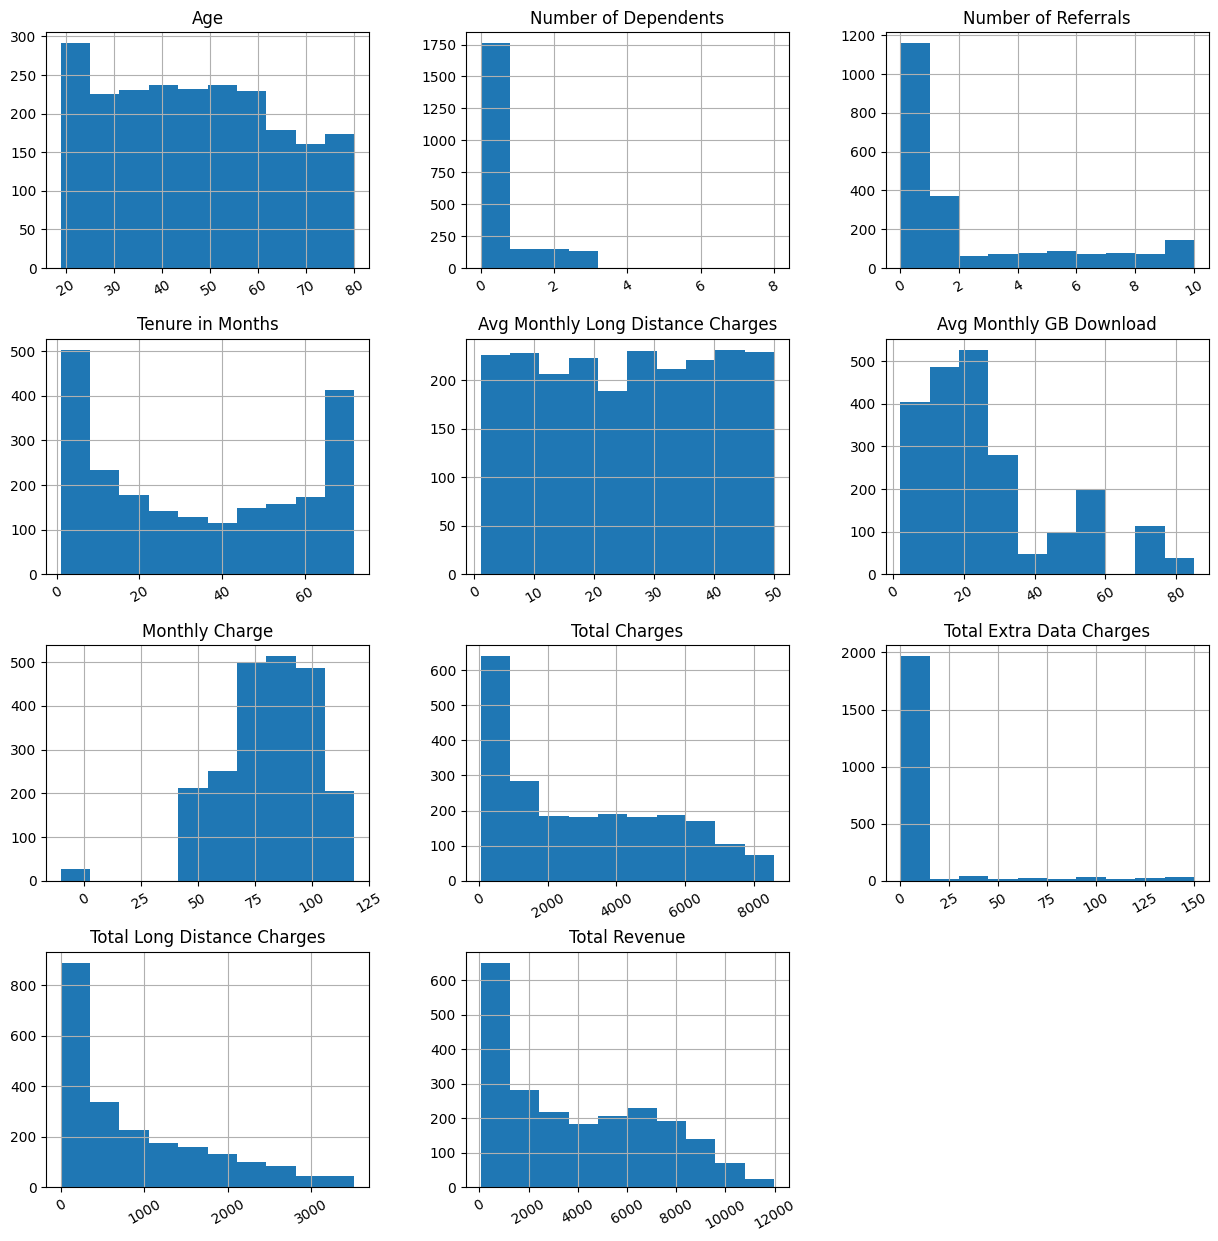

In [ ]:
df1.hist(figsize=(15,15), xrot=30)

In [ ]:
df1['Age']

,Age
2,50
3,78
5,23
6,67
7,52
...,...
7036,53
7038,20
7039,40
7040,22


In [ ]:
import matplotlib.pyplot as plt

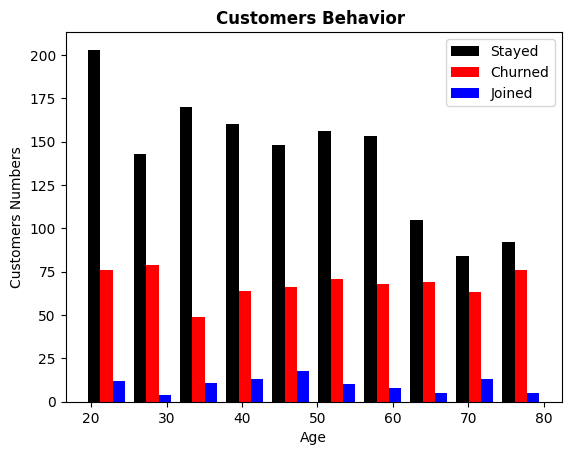

In [ ]:
Customer_Stayed=df1[df1['Customer Status']=='Stayed'].Age
Customer_Churned=df1[df1['Customer Status']=='Churned'].Age
Customer_Joined=df1[df1['Customer Status']=='Joined'].Age

plt.xlabel('Age')
plt.ylabel('Customers Numbers')
plt.hist([Customer_Stayed,Customer_Churned,Customer_Joined], color=['black','red','blue'],label=['Stayed','Churned','Joined'])

plt.title('Customers Behavior ',fontweight ="bold")
plt.legend()

In [ ]:
import seaborn as sns

In [41]:
df1.columns

Index(['Gender', 'Age', 'Married', 'Number of Dependents', 'City',
       'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status'],
      dtype='object')

<Axes: xlabel='Customer Status'>

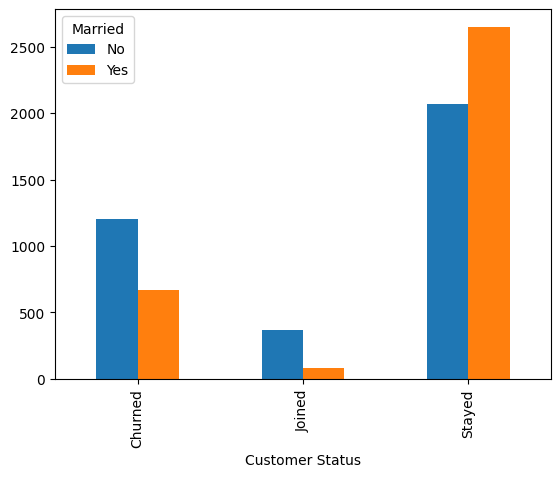

In [42]:
pd.crosstab(df['Customer Status'], df['Married']).plot(kind='bar')

<Axes: xlabel='Customer Status'>

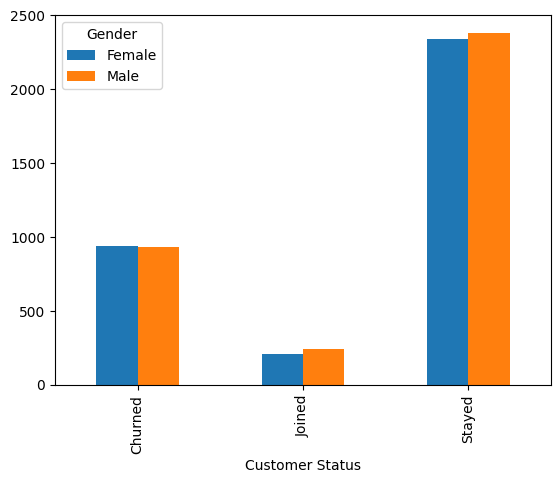

In [43]:
pd.crosstab(df['Customer Status'], df['Gender']).plot(kind='bar')

<Axes: xlabel='Customer Status'>

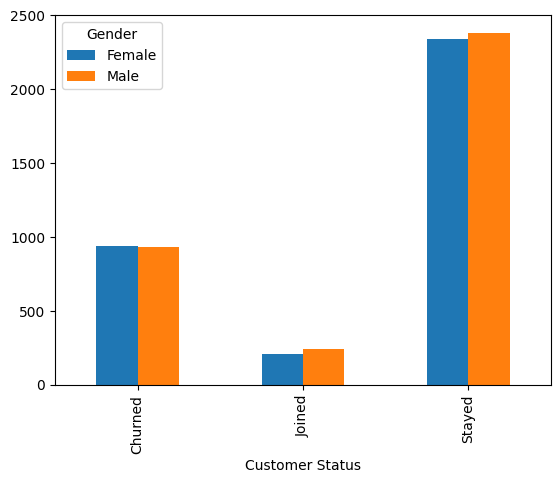

In [44]:
pd.crosstab(df['Customer Status'], df['Gender']).plot(kind='bar')

In [45]:
df1['Payment Method'].unique()

array(['Bank Withdrawal', 'Credit Card', 'Mailed Check'], dtype=object)

In [47]:
Roles = {}
for j in df1['Payment Method'].unique():
    Roles[j] = df1[df1['Payment Method'] == j]

In [48]:
Roles.keys()

dict_keys(['Bank Withdrawal', 'Credit Card', 'Mailed Check'])

In [49]:
Roles = {}
for j in df1['Payment Method'].unique():
    Roles[j] = df1[df1['Payment Method'] == j]


In [50]:
Roles.keys()

dict_keys(['Bank Withdrawal', 'Credit Card', 'Mailed Check'])

In [51]:
Roles['Credit Card']

,Gender,Age,Married,Number of Dependents,City,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,...,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status
5,Female,23,No,3,Midpines,0,9,Offer E,Yes,16.77,...,Yes,Month-to-Month,Yes,Credit Card,69.40,571.45,0,150.93,722.38,Stayed
7,Male,52,Yes,0,Napa,8,63,Offer B,Yes,12.96,...,No,Two Year,Yes,Credit Card,84.65,5377.80,20,816.48,6214.28,Stayed
15,Female,58,Yes,2,Woodlake,9,71,Offer A,Yes,27.26,...,Yes,Two Year,Yes,Credit Card,95.75,6849.40,0,1935.46,8784.86,Stayed
30,Male,23,Yes,3,Moss Beach,1,37,Offer C,Yes,43.01,...,Yes,One Year,No,Credit Card,91.20,3247.55,0,1591.37,4838.92,Stayed
41,Female,20,No,0,Fremont,0,27,Offer C,Yes,48.91,...,Yes,One Year,No,Credit Card,78.20,2078.95,0,1320.57,3399.52,Stayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7035,Female,20,No,0,Los Angeles,0,7,Offer E,Yes,36.49,...,Yes,One Year,Yes,Credit Card,94.05,633.45,0,255.43,888.88,Stayed
7036,Female,53,No,0,Hume,0,1,Offer E,Yes,42.09,...,Yes,Month-to-Month,Yes,Credit Card,70.15,70.15,0,42.09,112.24,Churned
7038,Female,20,No,0,La Mesa,0,13,Offer D,Yes,46.68,...,Yes,One Year,No,Credit Card,55.15,742.90,0,606.84,1349.74,Stayed
7040,Male,22,No,0,Elk,0,2,Offer E,Yes,18.62,...,Yes,Month-to-Month,Yes,Credit Card,50.30,92.75,0,37.24,129.99,Joined


In [52]:
off = df1['Offer'].value_counts()
off

,count
Offer,
Offer B,585
Offer E,544
Offer D,392
Offer A,382
Offer C,291


In [53]:
Roles['Credit Card']

,Gender,Age,Married,Number of Dependents,City,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,...,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status
5,Female,23,No,3,Midpines,0,9,Offer E,Yes,16.77,...,Yes,Month-to-Month,Yes,Credit Card,69.40,571.45,0,150.93,722.38,Stayed
7,Male,52,Yes,0,Napa,8,63,Offer B,Yes,12.96,...,No,Two Year,Yes,Credit Card,84.65,5377.80,20,816.48,6214.28,Stayed
15,Female,58,Yes,2,Woodlake,9,71,Offer A,Yes,27.26,...,Yes,Two Year,Yes,Credit Card,95.75,6849.40,0,1935.46,8784.86,Stayed
30,Male,23,Yes,3,Moss Beach,1,37,Offer C,Yes,43.01,...,Yes,One Year,No,Credit Card,91.20,3247.55,0,1591.37,4838.92,Stayed
41,Female,20,No,0,Fremont,0,27,Offer C,Yes,48.91,...,Yes,One Year,No,Credit Card,78.20,2078.95,0,1320.57,3399.52,Stayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7035,Female,20,No,0,Los Angeles,0,7,Offer E,Yes,36.49,...,Yes,One Year,Yes,Credit Card,94.05,633.45,0,255.43,888.88,Stayed
7036,Female,53,No,0,Hume,0,1,Offer E,Yes,42.09,...,Yes,Month-to-Month,Yes,Credit Card,70.15,70.15,0,42.09,112.24,Churned
7038,Female,20,No,0,La Mesa,0,13,Offer D,Yes,46.68,...,Yes,One Year,No,Credit Card,55.15,742.90,0,606.84,1349.74,Stayed
7040,Male,22,No,0,Elk,0,2,Offer E,Yes,18.62,...,Yes,Month-to-Month,Yes,Credit Card,50.30,92.75,0,37.24,129.99,Joined


In [54]:
off = df1['Offer'].value_counts()
off


,count
Offer,
Offer B,585
Offer E,544
Offer D,392
Offer A,382
Offer C,291


In [55]:
import plotly.graph_objects as go

In [56]:
fig = go.Figure([go.Bar(x=off.index, y=off.values)])
fig.show()

In [57]:
df1_off = Roles['Credit Card'].Offer.value_counts()
df1_off

,count
Offer,
Offer B,204
Offer A,171
Offer E,126
Offer D,119
Offer C,96


In [58]:
fig = go.Figure([go.Bar(x= df1_off.index, y=df1_off.values)])
fig.show()

In [59]:
df1 = df1.rename(columns = {'Customer Status':'Customer_Status'})

In [62]:
Roles1 = {}
for k in df1['Customer_Status'].unique():
    Roles1[k] = df1[df1['Customer_Status'] == k]
Roles1.keys()

dict_keys(['Churned', 'Stayed', 'Joined'])

In [63]:
df1_state = Roles1['Stayed'].Offer.value_counts()
df1_state


,count
Offer,
Offer B,497
Offer A,348
Offer D,250
Offer C,204
Offer E,115


In [67]:
df1.replace({"Gender":{'Female':0,'Male':1}},inplace=True)

In [69]:
yes_and_no=[  'Paperless Billing', 'Unlimited Data',
       'Streaming Movies', 'Streaming Music',  'Streaming TV',
       'Premium Tech Support', 'Device Protection Plan', 'Online Backup', 'Online Security',
       'Multiple Lines',  'Married']
for i in yes_and_no:
    df1.replace({'No':0,'Yes':1},inplace=True)

In [70]:
df1.replace({"Phone Service":{'Yes':1}},inplace=True)

In [71]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df1.Customer_Status = le.fit_transform(df1.Customer_Status)

In [72]:
df1 = pd.get_dummies(data=df1, columns=['Payment Method','Contract','Internet Type','Offer','City'])

In [73]:
cols_to_scale = ['Age','Number of Dependents','Number of Referrals','Tenure in Months','Avg Monthly Long Distance Charges','Avg Monthly GB Download','Monthly Charge', 'Total Charges',
       'Total Extra Data Charges', 'Total Long Distance Charges','Total Revenue']

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df1[cols_to_scale] = scaler.fit_transform(df1[cols_to_scale])

In [74]:
X = df1.drop('Customer_Status',axis='columns')
y = df1['Customer_Status']


In [75]:
X.head(5)

,Gender,Age,Married,Number of Dependents,Number of Referrals,Tenure in Months,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,...,City_Woodland Hills,City_Woody,City_Wrightwood,City_Yermo,City_Yorba Linda,City_Yorkville,City_Yreka,City_Yuba City,City_Yucaipa,City_Yucca Valley
2,1,0.508197,0,0.000,0.0,0.042254,1,0.666462,0,1,...,False,False,False,False,False,False,False,False,False,False
3,1,0.967213,1,0.000,0.1,0.169014,1,0.547386,0,1,...,False,False,False,False,False,False,False,False,False,False
5,0,0.065574,0,0.375,0.0,0.112676,1,0.321691,0,1,...,False,False,False,False,False,False,False,False,False,False
6,0,0.786885,1,0.000,0.1,0.985915,1,0.182598,0,1,...,False,False,False,False,False,False,False,False,False,False
7,1,0.540984,1,0.000,0.8,0.873239,1,0.243873,1,1,...,False,False,False,False,False,False,False,False,False,False


In [76]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=5)
len(X_train)

1755

In [77]:
X_train[:10]

,Gender,Age,Married,Number of Dependents,Number of Referrals,Tenure in Months,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,...,City_Woodland Hills,City_Woody,City_Wrightwood,City_Yermo,City_Yorba Linda,City_Yorkville,City_Yreka,City_Yuba City,City_Yucaipa,City_Yucca Valley
5086,1,0.213115,0,0.000,0.0,0.126761,1,0.135417,0,1,...,False,False,False,False,False,False,False,False,False,False
1686,0,0.000000,0,0.000,0.0,0.140845,1,0.815768,0,1,...,False,False,False,False,False,False,False,False,False,False
3655,1,0.737705,0,0.000,0.0,0.000000,1,0.154003,1,1,...,False,False,False,False,False,False,False,False,False,False
697,1,0.983607,1,0.000,0.1,0.408451,1,0.959967,1,1,...,False,False,False,False,False,False,False,False,False,False
6685,0,0.721311,0,0.000,0.0,0.478873,1,0.247549,1,1,...,False,False,False,False,False,False,False,False,False,False
5617,0,0.262295,0,0.000,0.0,0.084507,1,0.367034,1,1,...,False,False,False,False,False,False,False,False,False,False
2938,1,0.098361,0,0.000,0.0,0.873239,1,0.443423,1,1,...,False,False,False,False,False,False,False,False,False,False
6323,1,0.688525,0,0.000,0.0,0.000000,1,0.257557,0,1,...,False,False,False,False,False,False,False,False,False,False
3382,1,0.868852,0,0.000,0.0,0.014085,1,0.825368,0,1,...,False,False,False,False,False,False,False,False,False,False
1184,1,0.377049,1,0.375,0.8,0.774648,1,0.813725,1,1,...,False,False,False,False,False,False,False,False,False,False


In [78]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [79]:
model_params = {

    'random_forest': {
        'model': RandomForestClassifier(),
        'params' : {
            'n_estimators': [1,5,10]
        }
    },
    'logistic_regression' : {
        'model': LogisticRegression(solver='liblinear',multi_class='auto'),
        'params': {
            'C': [1,5,10]
        }
    },
    'naive_bayes_gaussian': {
        'model': GaussianNB(),
        'params': {}
    },

    'decision_tree': {
        'model': DecisionTreeClassifier(),
        'params': {
            'criterion': ['gini','entropy'],
        }
    },
       'XGB_Classifier':{
        'model':XGBClassifier(),
        'params':{
            'base_score':[0.5]

        }
    },
}


In [80]:
from sklearn.model_selection import ShuffleSplit

In [82]:
from sklearn.model_selection import GridSearchCV
scores = []
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
for model_name, mp in model_params.items():
    clf =  GridSearchCV(mp['model'], mp['params'], cv=cv, return_train_score=False)
    clf.fit(X,y)
    scores.append({
        'model': model_name,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })

df = pd.DataFrame(scores,columns=['model','best_score','best_params'])
df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will 

,model,best_score,best_params
0,random_forest,0.794533,{'n_estimators': 10}
1,logistic_regression,0.792711,{'C': 1}
2,naive_bayes_gaussian,0.374487,{}
3,decision_tree,0.787244,{'criterion': 'gini'}
4,XGB_Classifier,0.821868,{'base_score': 0.5}


In [83]:
reg=XGBClassifier()
reg.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [84]:
reg.score(X_test, y_test)

0.8154897494305239

In [85]:
y_predicted = reg.predict(X_test)
y_predicted[:5]


array([2, 0, 1, 0, 0])

In [86]:
y_test[:5]

,Customer_Status
525,2
3086,0
2231,1
5041,0
4165,0


Text(95.72222222222221, 0.5, 'Truth')

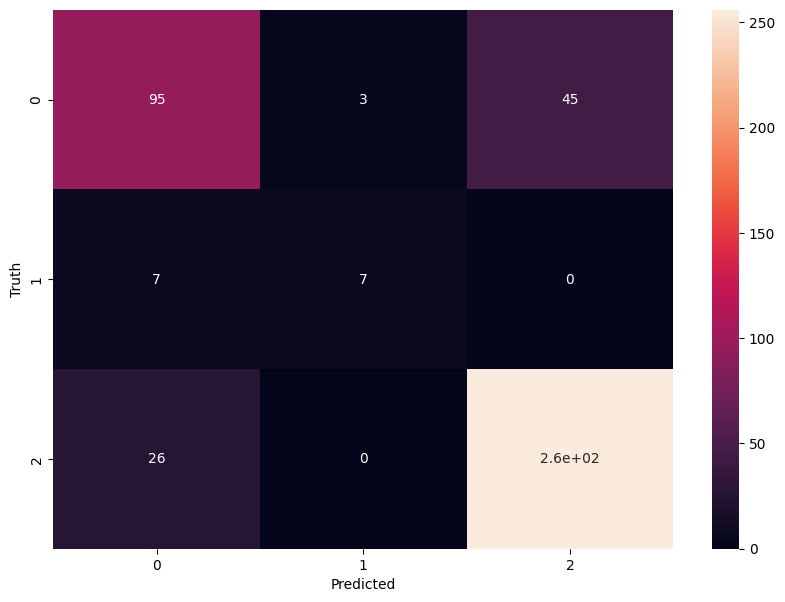

In [87]:
import seaborn as sn
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predicted)
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [88]:
from sklearn.metrics import classification_report

In [89]:
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.74      0.66      0.70       143
           1       0.70      0.50      0.58        14
           2       0.85      0.91      0.88       282

    accuracy                           0.82       439
   macro avg       0.76      0.69      0.72       439
weighted avg       0.81      0.82      0.81       439



In [90]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_predicted)

0.8154897494305239

In [ ]:
from sklearn.metrics import roc_auc_score, cohen_kappa_score, matthews_corrcoef

In [93]:
from sklearn.metrics import roc_auc_score, cohen_kappa_score, matthews_corrcoef

# Calculate ROC AUC Score (for multi-class, using 'ovr' strategy and 'weighted' averaging)
roc_auc = roc_auc_score(y_test, reg.predict_proba(X_test), multi_class='ovr', average='weighted')
print(f"ROC AUC Score (weighted): {roc_auc:.4f}")


ROC AUC Score (weighted): 0.9078


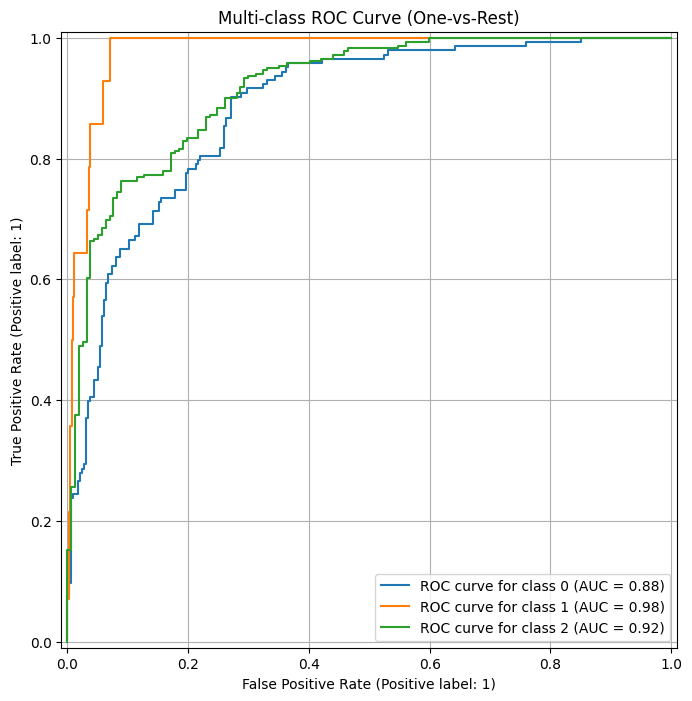

In [95]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Get the predicted probabilities for each class
y_score = reg.predict_proba(X_test)

# Get unique classes
classes = reg.classes_

plt.figure(figsize=(10, 8))
ax = plt.gca()

# Plot ROC curve for each class using One-vs-Rest (OvR) approach
for i, class_label in enumerate(classes):
    # Create a binary target for the current class (1 if it's the class, 0 otherwise)
    y_true_binary = (y_test == class_label).astype(int)
    # Get the probabilities for the current class
    y_score_class = y_score[:, i]

    RocCurveDisplay.from_predictions(y_true_binary, y_score_class, name=f'ROC curve for class {class_label}', ax=ax)

plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.grid(True)
plt.show()

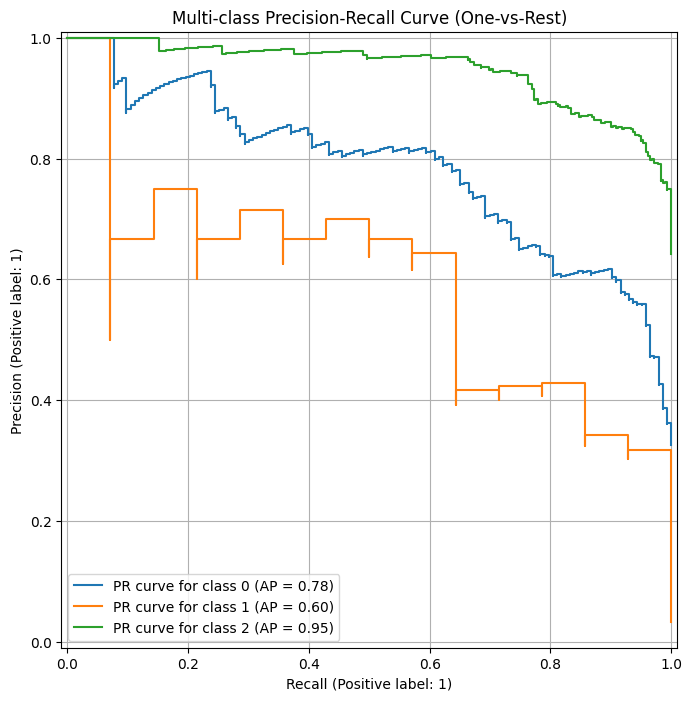

In [96]:
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve
import matplotlib.pyplot as plt

# Get the predicted probabilities for each class
y_score = reg.predict_proba(X_test)

# Get unique classes
classes = reg.classes_

plt.figure(figsize=(10, 8))
ax = plt.gca()

# Plot Precision-Recall curve for each class using One-vs-Rest (OvR) approach
for i, class_label in enumerate(classes):
    # Create a binary target for the current class (1 if it's the class, 0 otherwise)
    y_true_binary = (y_test == class_label).astype(int)
    # Get the probabilities for the current class
    y_score_class = y_score[:, i]

    PrecisionRecallDisplay.from_predictions(y_true_binary, y_score_class, name=f'PR curve for class {class_label}', ax=ax)

plt.title('Multi-class Precision-Recall Curve (One-vs-Rest)')
plt.grid(True)
plt.show()